# Friction Factors 
Creates Friction Factors based on calibrated gamma parameters in .dat format, ready to be consumed by CUBE application. 

In [12]:
from pathlib import Path
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [13]:
input_file = Path("../data/external/mtc/2023_TM161_IPA_35/nonres/truckFF.dat") # TM-1.6
output_file = Path("../models/trip_distribution/truckFF_distance_based.dat")
modified_output_file = Path("../models/trip_distribution/truckFF_modified_distance_based.dat")

## TM 1.6 - Gamma Distributions

In [14]:
df = pd.read_csv(
    input_file, 
    sep="\t", 
    header=None,
    names=["Time", "VerySmall", "Small", "Medium", "Large"]
)

Verified Column Sums:
VerySmall    1.0
Small        1.0
Medium       1.0
Large        1.0
dtype: float64


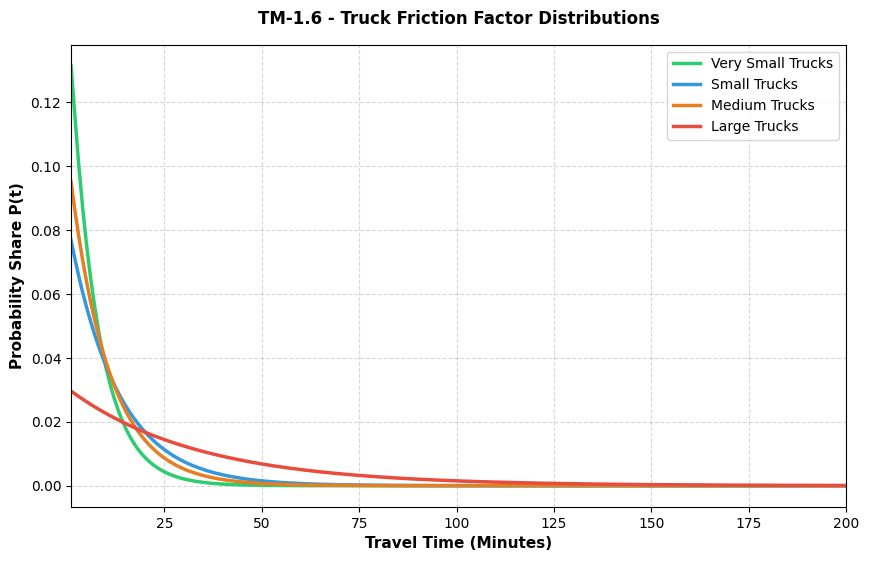

In [15]:
df_prob = df.copy()
for col in ["VerySmall", "Small", "Medium", "Large"]:
    df_prob[col] = df_prob[col] / df_prob[col].sum()

# Quick verification check to print out the new column sums (should all be 1.0)
print("Verified Column Sums:")
print(df_prob[["VerySmall", "Small", "Medium", "Large"]].sum())

# 3. Initialize the plot
plt.figure(figsize=(10, 6))

# 4. Plot the probability mass curves
plt.plot(df_prob["Time"], df_prob["VerySmall"], label="Very Small Trucks", color="#2ecc71", linewidth=2.5)
plt.plot(df_prob["Time"], df_prob["Small"], label="Small Trucks", color="#3498db", linewidth=2.5)
plt.plot(df_prob["Time"], df_prob["Medium"], label="Medium Trucks", color="#e67e22", linewidth=2.5)
plt.plot(df_prob["Time"], df_prob["Large"], label="Large Trucks", color="#e74c3c", linewidth=2.5)

# 5. Fine-tune visual parameters for probability layouts
plt.xlim(1, df_prob["Time"].max())
plt.xlabel("Travel Time (Minutes)", fontsize=11, fontweight="bold")
plt.ylabel("Probability Share P(t)", fontsize=11, fontweight="bold")
plt.title("TM-1.6 - Truck Friction Factor Distributions", fontsize=12, fontweight="bold", pad=15)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(fontsize=10, loc="upper right")

# Display the clean distribution plot
plt.show()

## TM 1.7 Gamma Distributions

In [16]:
# Gamma distribution parameters: First Value is a, second value is b, and third value is c 
# These values are estimated using src.models.trip_distribution.run
# Results in travel-model-one\utilities\trucks\trucks_2026_update\models\trip_distribution\summary.xlsx

# "a" scaling constant used to keep friction factors of similar magnitude of original ones. 
# We suspect this is an arbitrary number to avoid small numbers in the CUBE gravity model that 
# could result in a underflow problem. 

params = {
    "VerySmall": (1_000_000, -0.298691030173983, -0.138965559345925),
    "Small": (10_000, -0.01, -0.0877783337612346),  
    "Medium": (10_000, -0.122744088250086, -0.0578123711475591),  
    "Large": (10_000, -0.221471504811372, -0.00606085563803193)          
}

distance_ff = pd.DataFrame()
t = np.arange(1,201,1)
distance_ff["distance"] = t

for col, (a, b, c) in params.items():
    # Vectorized calculation over the entire 't' array at once
    raw_decimals = a * (t ** b) * np.exp(c * t)
    
    # Round and force to standard integer types
    distance_ff[col] = np.round(raw_decimals).astype(int)

Verified Column Sums:
VerySmall    1.0
Small        1.0
Medium       1.0
Large        1.0
dtype: float64


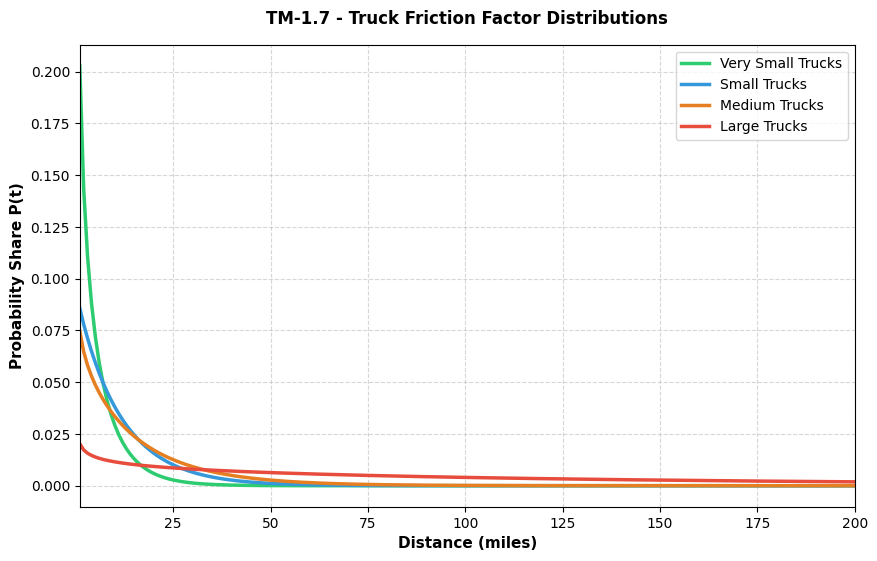

In [17]:
# Friction Factors PDFs
df_prob = distance_ff.copy()
for col in ["VerySmall", "Small", "Medium", "Large"]:
    df_prob[col] = df_prob[col] / df_prob[col].sum()

# Quick verification check to print out the new column sums (should all be 1.0)
print("Verified Column Sums:")
print(df_prob[["VerySmall", "Small", "Medium", "Large"]].sum())

# 3. Initialize the plot
plt.figure(figsize=(10, 6))

# 4. Plot the probability mass curves
plt.plot(df_prob["distance"], df_prob["VerySmall"], label="Very Small Trucks", color="#2ecc71", linewidth=2.5)
plt.plot(df_prob["distance"], df_prob["Small"], label="Small Trucks", color="#3498db", linewidth=2.5)
plt.plot(df_prob["distance"], df_prob["Medium"], label="Medium Trucks", color="#e67e22", linewidth=2.5)
plt.plot(df_prob["distance"], df_prob["Large"], label="Large Trucks", color="#e74c3c", linewidth=2.5)

# 5. Fine-tune visual parameters for probability layouts
plt.xlim(1, df_prob["distance"].max())
plt.xlabel("Distance (miles)", fontsize=11, fontweight="bold")
plt.ylabel("Probability Share P(t)", fontsize=11, fontweight="bold")
plt.title("TM-1.7 - Truck Friction Factor Distributions", fontsize=12, fontweight="bold", pad=15)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(fontsize=10, loc="upper right")

# Display the clean distribution plot
plt.show()

In [18]:
distance_ff

,distance,VerySmall,Small,Medium,Large
0,1,870258,9160,9438,9940
1,2,615717,8332,8182,8474
2,3,474714,7601,7347,7699
3,4,379107,6942,6694,7180
4,5,308648,6345,6147,6793
...,...,...,...,...,...
195,196,0,0,0,947
196,197,0,0,0,940
197,198,0,0,0,934
198,199,0,0,0,927


In [19]:
distance_ff = distance_ff.astype(int) # No floating decimals get written out
distance_ff.to_csv(
    output_file, 
    sep="\t", 
    header=False, 
    index=False
)

# Increase Large Trucks Average Distance

The motivation for increasing the average travel distance of large trucks is to evaluate whether it improves model calibration against observed data. Initial results showed a significant underprediction of large truck trips along I-80, particularly near Richmond and the Vallejo Bridge, however, there is not clear special generator near this location, so this is an alternative test to check if it helps improve model calibration. 

This experiment modifies the C parameter, which controls the distance decay function.

We want to test this hypothesis because the Port of Oakland is located near these locations. It is possible that the model is keeping too many truck trips local or within the nearby region, and therefore, these are not using I-80 highway. 

In [20]:
# Gamma distribution parameters: First Value is a, second value is b, and third value is c 
# These values are estimated using src.models.trip_distribution.run
# Results in travel-model-one\utilities\trucks\trucks_2026_update\models\trip_distribution\summary.xlsx

# "a" scaling constant used to keep friction factors of similar magnitude of original ones. 
# We suspect this is an arbitrary number to avoid small numbers in the CUBE gravity model that 
# could result in a underflow problem. 

params = {
    "VerySmall": (1_000_000, -0.298691030173983, -0.138965559345925),
    "Small": (10_000, -0.01, -0.0877783337612346),  
    "Medium": (10_000, -0.122744088250086, -0.0578123711475591),  
    "Large": (10_000, -0.221471504811372, -0.00606085563803193), 
    "Large_modified":  (10_000, -0.221471504811372, -0.00106085563803193), 
}

modified_distance_ff = pd.DataFrame()
t = np.arange(5,201, 5)
modified_distance_ff["distance"] = t

for col, (a, b, c) in params.items():
    # Vectorized calculation over the entire 't' array at once
    raw_decimals = a * (t ** b) * np.exp(c * t)
    
    # Round and force to standard integer types
    modified_distance_ff[col] = np.round(raw_decimals).astype(int)

Verified Column Sums:
Large_modified    1.0
Large             1.0
dtype: float64


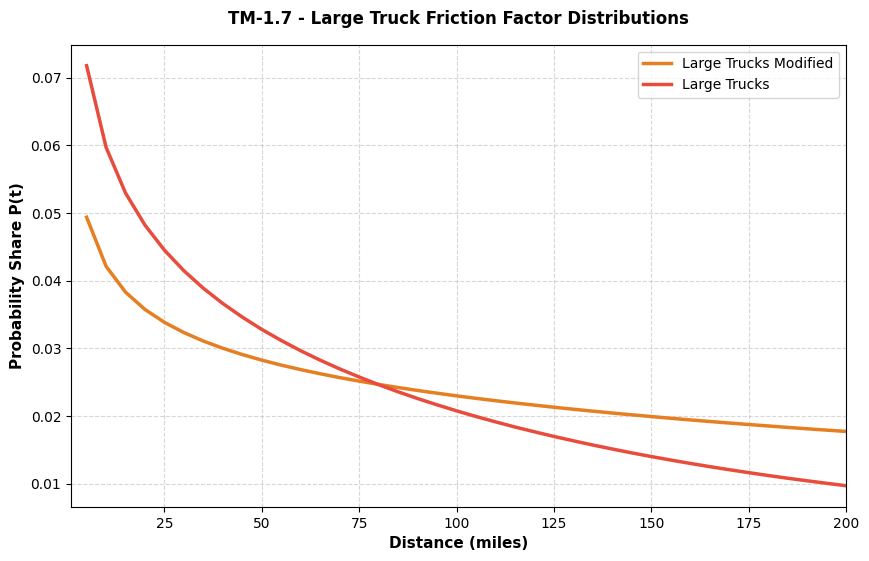

In [21]:
df_probs = modified_distance_ff.copy()
cols = ["Large_modified", "Large"]
for col in cols:
    df_probs[col] = df_probs[col] / df_probs[col].sum()

# Quick verification check to print out the new column sums (should all be 1.0)
print("Verified Column Sums:")
print(df_probs[cols].sum())

# 3. Initialize the plot
plt.figure(figsize=(10, 6))

# 4. Plot the probability mass curves
plt.plot(df_probs["distance"], df_probs["Large_modified"], label="Large Trucks Modified", color="#e67e22", linewidth=2.5)
plt.plot(df_probs["distance"], df_probs["Large"], label="Large Trucks", color="#e74c3c", linewidth=2.5)

# 5. Fine-tune visual parameters for probability layouts
plt.xlim(1, df_probs["distance"].max())
plt.xlabel("Distance (miles)", fontsize=11, fontweight="bold")
plt.ylabel("Probability Share P(t)", fontsize=11, fontweight="bold")
plt.title("TM-1.7 - Large Truck Friction Factor Distributions", fontsize=12, fontweight="bold", pad=15)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(fontsize=10, loc="upper right")

# Display the clean distribution plot
plt.show()

In [22]:
# Drop "Large" and rename "Large_modified" to "Large"
modified_distance_ff = modified_distance_ff.drop(columns="Large").rename(columns = {"Large_modified":"Large"})

In [23]:
modified_distance_ff

,distance,VerySmall,Small,Medium,Large
0,5,308648,6345,6147,6965
1,10,125253,4062,4228,5942
2,15,55390,2609,3013,5403
3,20,25372,1677,2178,5042
4,25,11848,1079,1588,4774
5,30,5601,694,1163,4561
6,35,2670,447,854,4384
7,40,1281,288,630,4234
8,45,617,185,465,4103
9,50,298,119,344,3987


In [24]:
modified_distance_ff = modified_distance_ff.astype(int) # No floating decimals get written out
modified_distance_ff.to_csv(
    modified_output_file, 
    sep="\t", 
    header=False, 
    index=False
)